# Introduction: The Boston Housing Dataset

The dataset you'll work with in this assignment comes from a 1978 study about how house prices are related to clean air.  The dataset includes a training set with 404 examples and a test set with 102 examples, for a roughly 80/20, train/test split.  Like the MNIST handwritten digit recognition dataset, the Boston housing data is conveniently included in Keras.

Each example corresponds to a single house and bears 13 input variables describing various properties of that house, along with one output variable containing the price of the house.

All of the variables are numeric, but from variable to variable the range of values taken on varies, which means that standardizing the input data before using it in a model will be necessary.

You can read more about the data set [here](https://keras.io/api/datasets/boston_housing/), including links to descriptions of the model features.  The model's targets are in units of $1K.  You'll also notice an ethics warning in the dataset description, which points to the sort of issue that every practitioner of data science or ML should be mindful of as they work.

Throughout this assignment watch for **TODO** markers where you're supposed to complete code, and sections whose name starts with **QUESTION**, where you're supposed to answer some questions in text cells.

# Getting Started


## Typical Keras Imports

In [1]:
# You'll probably either cut and paste, or eventually rattle off from memory,
# lines like this at the start of every deep learning thing you ever do...
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import numpy as np
import logging

2023-08-20 23:15:51.534061: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-20 23:15:52.528196: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/intel/compilers_and_libraries_2018.1.163/linux/tbb/lib/intel64_lin/gcc4.7:/opt/intel/compilers_and_libraries_2018.1.163/linux/compiler/lib/intel64_lin:/opt/intel/compilers_and_libraries_2018.1.163/linux/mkl/lib/intel64_lin::/usr/local/cuda/lib64:/usr/local/cuda/extras/CUPTI/lib64/
2023-08-20 23:15:52.528333: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not

In [2]:
# Define some constants for use throughout...
EPOCHS = 500
BATCH_SIZE = 32

## Reading the Data

As we mentioned, the Boston housing data is distributed with Keras.

In [3]:
boston_housing = keras.datasets.boston_housing

# You might want to consult: https://keras.io/api/datasets/boston_housing/#load_data-function
# to see just what load_data is giving you back.
(x_train_raw, y_train), (x_test_raw, y_test) = boston_housing.load_data()

# TODO: Print out the shapes of the four subsets of the dataset above
for s in [x_train_raw, y_train, x_test_raw, y_test]:
    print(s.shape)

(404, 13)
(404,)
(102, 13)
(102,)


## QUESTION: Examining the Input Data's Shapes

When starting work with a dataset, it's always a good idea to inspect it and see how much data it contains, and what the shape of that data is.

1.   What are the dimensions of each of the four subsets of the dataset you loaded in the previous cell, i.e. the train and test inputs and outputs?
The dimensions of the four subsets are: x_train is 404 by 13, y_train is 404 by 1, x_test is 102 by 13, and lastly y_test is 102 by 1.
2.   Do the dimensions match what was claimed in the preamble to this notebook?
The preamble claim the data should be divided into 404 training examples and 102 testing examples which matches the above.

## Standardizing the Input Data

Standardize the features in the input data, by subtracting off the mean of each feature, and dividing by the feature's standard deviation, i.e.  

$$
{ (X-\mu) \over \sigma }
$$


In [4]:
#: Compute means and standard deviations for the raw training set
x_mean = x_train_raw.mean()
x_std  = x_train_raw.std()

In [5]:
#: Standardize the raw training and test sets
x_train = (x_train_raw - x_mean) / x_std
x_test  = (x_test_raw  - x_mean) / x_std

# Creating a Basic Neural Network Model

We're going to try fitting a neural net based regression model using a network with:
  - one fully connected (`Dense` in Keras) layer of 64 units, with 'relu' activation, set up to take our input layer which has 13 units
  - a second fully connected layer of 64 units, also with 'relu' activation
  - an output layer of a single unit, with 'linear' activation (recall we use linear output units for regression problems).


In [6]:
from keras.api._v2.keras import activations, layers

# Create the model object
model = Sequential(name="64R/64R/1L") # NOTE: You can choose meaningful names to put on model objects!
# TODO: Add the first hidden layer
model.add(keras.Input(shape=(13,)))
model.add(layers.Dense(64, activation='relu'))
# TODO: Add the second hidden layer
model.add(layers.Dense(64, activation='relu'))
# TODO: Add the output layer
model.add(layers.Dense(1,activation='linear'))

2023-08-20 23:15:54.001700: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-20 23:15:54.844576: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14540 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0001:00:00.0, compute capability: 7.0


In [7]:
# TODO: Have Keras print a summary of your model.
#       Convince yourself the number of trainable parameters makes sense for
#       each layer. The notation for describing layers and their parameters
#       from lecture 2 might be helpful in organizing your thoughts as you
#       check.
model.summary()

Model: "64R/64R/1L"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5,121
Trainable params: 5,121
Non-trainable params: 0
_________________________________________________________________


## Compile the Model


In [8]:
# from keras.engine.training import optimizer
from keras.optimizers import Adam
mse = tf.keras.losses.MeanSquaredError()
mae = tf.keras.metrics.MeanAbsoluteError()
# TODO: Compile the model using the mean squared error loss function, the adam
#       optimizer, and mean absolute error in your metrics.  You might need to
#       consult the Keras documentation at https://keras.io/api/ or things we
#       demo'ed in class to get the specific details of the various
#       incantations.
model.compile(loss = mse,        # You might have to look up just how to specify mean absolute error
              optimizer= 'adam', # You'll have to look up how to name Adam here, it's not tricky
              metrics=[mae])     # You might also have to look up just how to specify mean absolute error

## Train the Model

In [9]:
# TODO: Train your model on the standardized training data.
#       Pass the test sets as your validation data.  Use the
#       number of epochs and batch size set in the EPOCHS
#       and BATCH_SIZE variables from the start of the notebook.
#
#       Also pass 'shuffle=True' and consult the Keras documentation
#       for model.fit() to understand what it's doing

history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, 
                    epochs=EPOCHS, validation_data=(x_test,y_test), shuffle=True)

Epoch 1/500


2023-08-20 23:15:56.749857: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7f68a001c670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-08-20 23:15:56.749902: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100-PCIE-16GB, Compute Capability 7.0
2023-08-20 23:15:56.757762: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-08-20 23:15:56.911651: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 [==============================] - 2s 18ms/step - loss: 575.3897 - mean_absolute_error: 22.1478 - val_loss: 557.4896 - val_mean_absolute_error: 21.7191
Epoch 2/500
13/13 [==============================] - 0s 5ms/step - loss: 493.8564 - mean_absolute_error: 20.2016 - val_loss: 474.8645 - val_mean_absolute_error: 19.6712
Epoch 3/500
13/13 [==============================] - 0s 5ms/step - loss: 408.9065 - mean_absolute_error: 17.8647 - val_loss: 373.2368 - val_mean_absolute_error: 16.8466
Epoch 4/500
13/13 [==============================] - 0s 6ms/step - loss: 302.5493 - mean_absolute_error: 14.6352 - val_loss: 258.7809 - val_mean_absolute_error: 13.4314
Epoch 5/500
13/13 [==============================] - 0s 5ms/step - loss: 195.1881 - mean_absolute_error: 10.8345 - val_loss: 158.7363 - val_mean_absolute_error: 9.7868
Epoch 6/500
13/13 [==============================] - 0s 5ms/step - loss: 122.9589 - mean_absolute_error: 8.0819 - val_loss: 115.6744 - val_mean_absolute_error: 8.0463


In [10]:
history.history.keys()

dict_keys(['loss', 'mean_absolute_error', 'val_loss', 'val_mean_absolute_error'])

In [11]:
# Calling model.fit(), returns a Keras history object which
# records the loss values and metrics values logged during training.
# We can use the history to analyze a training run, plot
# performance related data, etc.
#
# The history object is a dictionary... Stop now, and look at what
# keys wound up in the history associated with our prior training run...
print(history.history.keys())

# Notice that for each of the logged quantities we end up with
# a recording of the values assumed throughout the epochs of our
# training run, so the sequence length corresponds to how many
# epochs we trained for.
assert len(history.history['loss']) == EPOCHS

print(len(history.history['loss']))
print(len(history.history['mean_absolute_error']))
print(len(history.history['val_loss']))
print(len(history.history['val_mean_absolute_error']))

# As we mentioned we can use the recorded histories to inform us.
# Later, we'll also meet other ways to track and influence the
# training process.

dict_keys(['loss', 'mean_absolute_error', 'val_loss', 'val_mean_absolute_error'])
500
500
500
500


### Helper Function: `plot_train_and_val_quantities`

In [12]:
from matplotlib import pyplot as plt
%matplotlib inline

def plot_train_and_val_quantities(train_quantity_per_epoch,
                                  val_quantity_per_epoch,
                                  quantity_name=None,
                                  plot_title=None):
    """Plot the given training and value histories"""
    assert len(train_quantity_per_epoch) == len(val_quantity_per_epoch)
    epochs = range(0,len(train_quantity_per_epoch))
    plt.figure()
    plt.grid()
    plt.plot(epochs, train_quantity_per_epoch, color='orange') # 'tangerine' for 'train'
    plt.plot(epochs, val_quantity_per_epoch, color='violet')   # 'violet' for 'validation'
    if quantity_name is not None:
        plt.legend([f"train {quantity_name}", f"val {quantity_name}"])
    plt.ylabel(quantity_name)
    plt.xlabel("epoch")
    if plot_title is not None:
        plt.title(plot_title)
    plt.show()

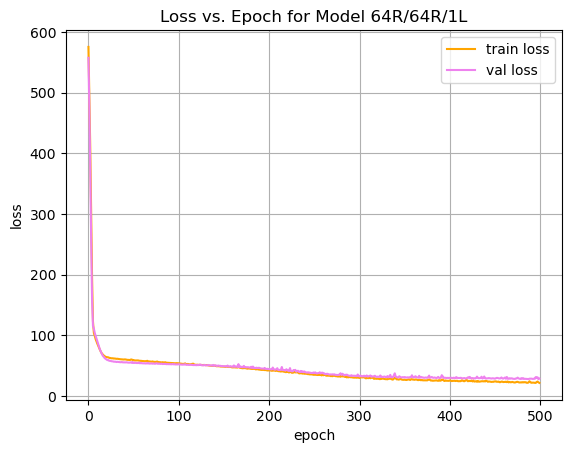

In [13]:
loss_per_epoch = history.history['loss']
val_loss_per_epoch = history.history['val_loss']

plot_train_and_val_quantities(loss_per_epoch, val_loss_per_epoch,
                              "loss",
                              f"Loss vs. Epoch for Model {model.name}")

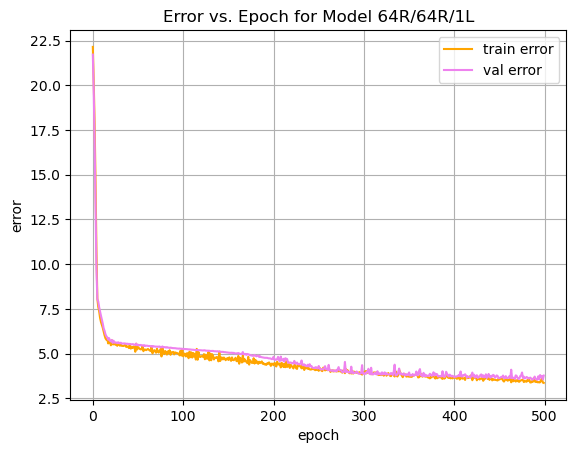

In [14]:
error_per_epoch = history.history['mean_absolute_error']
val_error_per_epoch = history.history['val_mean_absolute_error']

plot_train_and_val_quantities(error_per_epoch, val_error_per_epoch,
                              "error",
                              f"Error vs. Epoch for Model {model.name}")

### Helper Function: `print_errors_at_last_epoch`

In [15]:
def print_errors_at_last_epoch(errors, val_errors):
    """Print final values of training and validation errors"""
    assert len(errors) == len(val_errors)
    final_error = errors[-1]
    final_val_error = val_errors[-1]
    print(f"final_error: {final_error}")
    print(f"final val error: {final_val_error}")
    final_val_minus_train = final_val_error - final_error
    print(f"final val - final train: {final_val_minus_train}")

In [16]:
# So where did our training and validation errors end up at end of epochs?
print_errors_at_last_epoch(error_per_epoch, val_error_per_epoch)

final_error: 3.3626348972320557
final val error: 3.772608757019043
final val - final train: 0.4099738597869873


## Eyeball Some Model Predictions

In [17]:
# TODO: Run your model on the test set and see what it predicts.
predictions = model.predict(x_test)

4/4 [==============================] - 0s 2ms/step


In [18]:
mse

### Helper Function: `compare_predictions_with_targets`

In [19]:
def compare_predictions_with_targets(predictions, targets, verbose=False):
    assert len(predictions) == len(targets)
    preds_and_targets = zip(predictions, targets)

    total_absolute_percent_error = 0.0
    num_entries = 0

    for (p,t) in preds_and_targets:
        absolute_percent_error = np.abs( (p-t)/t * 100.0 )
        num_entries += 1
        total_absolute_percent_error += absolute_percent_error
    if verbose:
        print(f"Prediction: {p}, Truth: {t}, Abs. Percent Error: {absolute_percent_error}")

    average_absolute_percent_error = total_absolute_percent_error/num_entries
    print(f"\nAverage Absolute Percentage Error: {average_absolute_percent_error}")

In [20]:
# How'd we do on the first ten predictions?
compare_predictions_with_targets(predictions[:10], y_test[:10], True)

Prediction: [21.683155], Truth: 23.2, Abs. Percent Error: [6.538128]

Average Absolute Percentage Error: [14.966721]


In [21]:
# And across the whole dataset how did we make out...?
compare_predictions_with_targets(predictions, y_test)


Average Absolute Percentage Error: [18.312122]


## Did We Gain Anything From Having More Layers?

Let's compare the model you just constructed and trained to a simple linear regression model.  Remember that in their heart of hearts, deep neural networks are just about curve fitting, and without nonlinear activations, a deep neural network degenerates into a boring, linear model, as we showed in class with a bit of matrix algebra.

Now, we'll implement plain, old linear regression as a neural network, and see how linear regression does on the data, as compared to the neural network with two hidden layers, each with nonlinear ReLU activations, and each of which is relatively beefy in unit count, compared to the number of input units.

In [22]:
linear_model = Sequential(name="1L")

# The world's most sad and forlorn neural network... Just linear regression
# with an overly ornate version of gradient descent used to train it.
linear_model.add(Dense(1, activation='linear', input_shape=[13]))

linear_model.compile(loss='mean_squared_error',
                     optimizer='adam',
                     metrics=['mean_absolute_error'])

linear_history = linear_model.fit(
                                  x_train, y_train,
                                  validation_data=(x_test, y_test),
                                  epochs=EPOCHS,
                                  batch_size=BATCH_SIZE,
                                  verbose=2,
                                  shuffle=True
                                 )

Epoch 1/500
13/13 - 1s - loss: 525.4673 - mean_absolute_error: 20.9533 - val_loss: 549.9458 - val_mean_absolute_error: 21.5416 - 713ms/epoch - 55ms/step
Epoch 2/500
13/13 - 0s - loss: 520.3182 - mean_absolute_error: 20.8277 - val_loss: 544.5936 - val_mean_absolute_error: 21.4147 - 63ms/epoch - 5ms/step
Epoch 3/500
13/13 - 0s - loss: 515.2454 - mean_absolute_error: 20.7031 - val_loss: 539.2922 - val_mean_absolute_error: 21.2882 - 57ms/epoch - 4ms/step
Epoch 4/500
13/13 - 0s - loss: 510.1482 - mean_absolute_error: 20.5799 - val_loss: 534.0928 - val_mean_absolute_error: 21.1634 - 67ms/epoch - 5ms/step
Epoch 5/500
13/13 - 0s - loss: 505.1804 - mean_absolute_error: 20.4566 - val_loss: 528.9041 - val_mean_absolute_error: 21.0380 - 54ms/epoch - 4ms/step
Epoch 6/500
13/13 - 0s - loss: 500.2215 - mean_absolute_error: 20.3332 - val_loss: 523.7662 - val_mean_absolute_error: 20.9133 - 54ms/epoch - 4ms/step
Epoch 7/500
13/13 - 0s - loss: 495.3282 - mean_absolute_error: 20.2108 - val_loss: 518.6633 

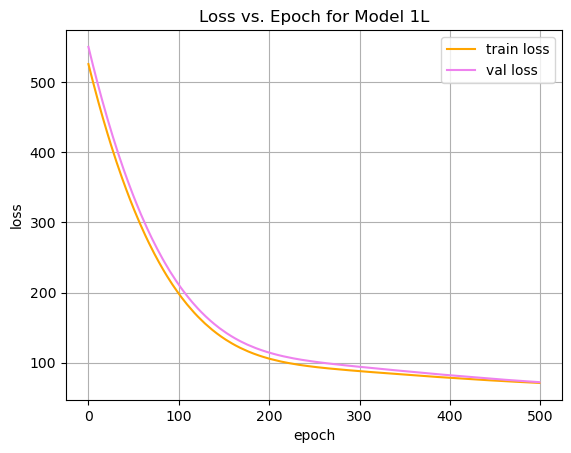

In [23]:
linear_loss_per_epoch = linear_history.history['loss']
linear_val_loss_per_epoch = linear_history.history['val_loss']

plot_train_and_val_quantities(linear_loss_per_epoch, linear_val_loss_per_epoch,
                              "loss",
                              f"Loss vs. Epoch for Model {linear_model.name}")

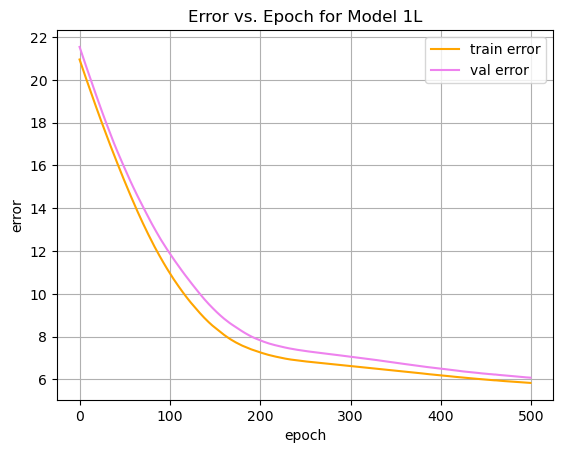

In [24]:
linear_mae_per_epoch = linear_history.history['mean_absolute_error']
linear_val_mae_per_epoch = linear_history.history['val_mean_absolute_error']

plot_train_and_val_quantities(linear_mae_per_epoch, linear_val_mae_per_epoch,
                              "error",
                              f"Error vs. Epoch for Model {linear_model.name}")

In [25]:
print_errors_at_last_epoch(linear_mae_per_epoch, linear_val_mae_per_epoch)

final_error: 5.834946632385254
final val error: 6.07984733581543
final val - final train: 0.24490070343017578


In [26]:
# Now see how our linear regression model did...
linear_predictions = linear_model.predict(x_test)

compare_predictions_with_targets(linear_predictions, y_test)

4/4 [==============================] - 0s 1ms/step

Average Absolute Percentage Error: [33.59992]


## QUESTION: Comparing the Neural Net to Vanilla Linear Regression

1. What average absolute percentage error did you get, over all the samples for the deep model?
The average abosolute percentage error for the deep model is 18.20%
1. What average absolute percentage error did you get, over all samples for the linear model, which lacked any hidden layers?
The average absolute percenteage error for the linear model that lacks any hidden layers is 34.25%.
1. Does it seem to you that the relatively small neural network has more model capacity than a straightforward linear regression? Where do you think this greater model capacity is coming from?
Absolutely, I think it's clear from the percentages that the NN is superior to the rigid linear regression model. I'm not quite sure where this performance gain originates form in terms of the NN, clearly it's more accurate but it's not clear to me why.

# Improving Performance with Regularization

Make a note of the errors you saw on training and test for the neural network you first trained, above.  You'll now try to do better by applying some of the regularization techniques discussed in class.

## L2 Regularization

In [27]:
from tensorflow.keras.regularizers import l2

l2_reg_model = Sequential(name="64R-L2/64R-L2/1L-L2")

l2_reg_model.add(Dense(64, activation='relu',
                  kernel_regularizer=l2(0.1),
                  bias_regularizer=l2(0.1),
                  input_shape=[13]))

l2_reg_model.add(Dense(64, activation='relu',
                  kernel_regularizer=l2(0.1),
                  bias_regularizer=l2(0.1))),

l2_reg_model.add(Dense(1, activation='linear',
                       kernel_regularizer=l2(0.1), # TODO: Use l2 with lambda = 0.1
                       bias_regularizer=l2(0.1)))  # TODO: Use l2 with lambda = 0.1

In [28]:
l2_reg_model.compile(loss = mse,
              optimizer= 'adam',
              metrics=[mae])

l2_reg_history = l2_reg_model.fit(x_train, y_train,
                                  validation_data=(x_test, y_test),
                                  epochs=EPOCHS,
                                  batch_size=BATCH_SIZE,
                                  verbose=2,
                                  shuffle=True)

Epoch 1/500
13/13 - 1s - loss: 541.6483 - mean_absolute_error: 17.6499 - val_loss: 529.6016 - val_mean_absolute_error: 20.8863 - 1s/epoch - 105ms/step
Epoch 2/500
13/13 - 0s - loss: 468.4887 - mean_absolute_error: 19.3357 - val_loss: 444.1328 - val_mean_absolute_error: 18.6765 - 61ms/epoch - 5ms/step
Epoch 3/500
13/13 - 0s - loss: 375.9561 - mean_absolute_error: 16.6929 - val_loss: 331.3320 - val_mean_absolute_error: 15.4745 - 63ms/epoch - 5ms/step
Epoch 4/500
13/13 - 0s - loss: 257.9414 - mean_absolute_error: 12.9715 - val_loss: 211.5162 - val_mean_absolute_error: 11.6665 - 62ms/epoch - 5ms/step
Epoch 5/500
13/13 - 0s - loss: 158.0149 - mean_absolute_error: 9.1161 - val_loss: 131.3994 - val_mean_absolute_error: 8.3024 - 61ms/epoch - 5ms/step
Epoch 6/500
13/13 - 0s - loss: 111.1145 - mean_absolute_error: 7.3758 - val_loss: 114.9223 - val_mean_absolute_error: 7.8339 - 64ms/epoch - 5ms/step
Epoch 7/500
13/13 - 0s - loss: 104.1677 - mean_absolute_error: 7.3549 - val_loss: 109.1323 - val_m

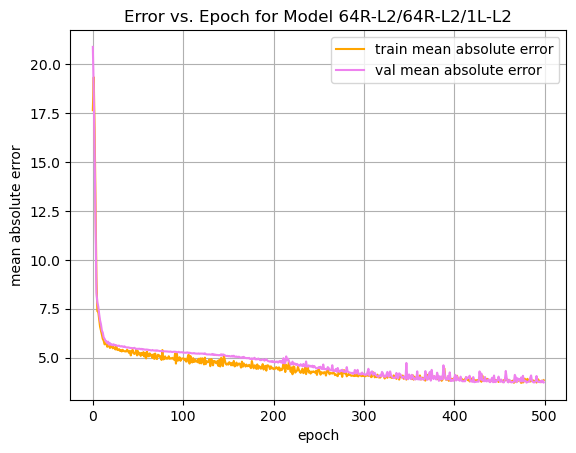

In [29]:
l2_error = l2_reg_history.history['mean_absolute_error']
l2_val_error = l2_reg_history.history['val_mean_absolute_error']

plot_train_and_val_quantities(l2_error, l2_val_error,
                              "mean absolute error",
                              f"Error vs. Epoch for Model {l2_reg_model.name}")

In [30]:
print_errors_at_last_epoch(l2_error, l2_val_error)

final_error: 3.845937967300415
final val error: 3.7335002422332764
final val - final train: -0.11243772506713867


## Dropout Regularization

In [31]:
from tensorflow.keras.layers import Dropout # Note we do Dropout by inserting a special layer!
                                            # This is different from how we added kernel and bias
                                            # regularizaers *to* existing layers themselves above.

dropout_model = Sequential(name="64R-D/64R-D/1L")

dropout_model.add(Dense(64, activation='relu', input_shape=(13,)))
dropout_model.add(Dropout(0.20)) # TODO: Add a Dropout layer with rate 0.20
dropout_model.add(Dense(64, activation='relu'))
dropout_model.add(Dropout(0.20)) # TODO: Add a Dropout layer with rate 0.20
dropout_model.add(Dense(1, activation='linear')) # NOTE: no dropout here... think why?

In [32]:
# TODO: Compile the Dropout-regularized model as you did before...
dropout_model.compile(loss = mse,
              optimizer= 'adam',
              metrics=[mae])

# TODO: Fit the Dropout-regularized model as you did before...
dropout_history = dropout_model.fit(x_train, y_train,
                                  validation_data=(x_test, y_test),
                                  epochs=EPOCHS,
                                  batch_size=BATCH_SIZE,
                                  verbose=2, 
                                  shuffle=True)

Epoch 1/500
13/13 - 2s - loss: 534.0197 - mean_absolute_error: 17.6161 - val_loss: 523.7227 - val_mean_absolute_error: 20.8114 - 2s/epoch - 117ms/step
Epoch 2/500
13/13 - 0s - loss: 461.8022 - mean_absolute_error: 19.2065 - val_loss: 436.1710 - val_mean_absolute_error: 18.4753 - 79ms/epoch - 6ms/step
Epoch 3/500
13/13 - 0s - loss: 364.5291 - mean_absolute_error: 16.3720 - val_loss: 322.9218 - val_mean_absolute_error: 15.2941 - 65ms/epoch - 5ms/step
Epoch 4/500
13/13 - 0s - loss: 260.4730 - mean_absolute_error: 13.0268 - val_loss: 209.8956 - val_mean_absolute_error: 11.7901 - 68ms/epoch - 5ms/step
Epoch 5/500
13/13 - 0s - loss: 163.8515 - mean_absolute_error: 9.7913 - val_loss: 143.2619 - val_mean_absolute_error: 9.2327 - 65ms/epoch - 5ms/step
Epoch 6/500
13/13 - 0s - loss: 139.6724 - mean_absolute_error: 8.8900 - val_loss: 131.8546 - val_mean_absolute_error: 8.7241 - 67ms/epoch - 5ms/step
Epoch 7/500
13/13 - 0s - loss: 117.7141 - mean_absolute_error: 8.3129 - val_loss: 122.1549 - val_m

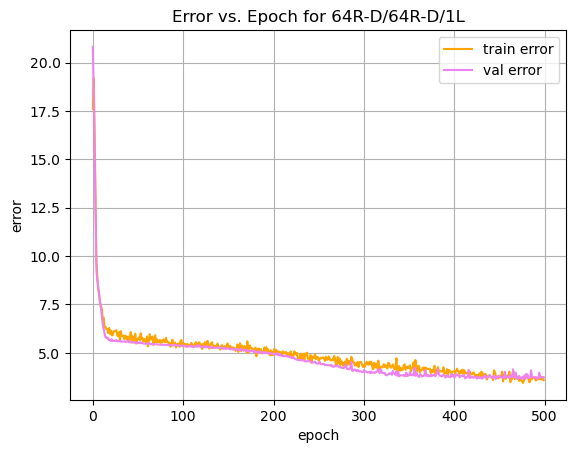

In [33]:
dropout_error = dropout_history.history['mean_absolute_error']
dropout_val_error = dropout_history.history['val_mean_absolute_error']

plot_train_and_val_quantities(dropout_error, dropout_val_error,
                              "error",
                              f"Error vs. Epoch for {dropout_model.name}")

In [34]:
print_errors_at_last_epoch(dropout_error, dropout_val_error)

final_error: 3.5883121490478516
final val error: 3.7336368560791016
final val - final train: 0.14532470703125


## QUESTION: Comparing L2 and Dropout Regularization

Compare your plots for the deep network when you ran it without regularization, with L2 regularization, and with dropout regularization.

1. How do the three scenarios compare in terms of how their training error trends develop, and where there training errors land by the end of the 500th epoch?
The network that ran without regularization appears to perform best, then the dropout regularization network ran second best with the L2 regularization network running compratively the worst. The difference in performance between the networks that employed regularization was however minor, with the difference in error being about 0.3. The error for the network that ran without regularization had the lowest error with it being just over 0.8.
1. Which of the three scenarios had the best training error?
The network that ran without regularization.
1. Which of the three scenarios seems to generalize best to the validation data?
This is where it gets interesting, the network that utilized L2 regularization ended up generalizing best to the validation data.
1. For the scenario that generalizes best to the validation data, how does its training error compare to the best training error of the trio?
The network that utilized the L2 regularization also had a commendable error, though it wasn't the lowest.
1. Based on the performance of the three methods you've seen so far, which regularization technique would you decide to use?
I would probably use the network that uses L2 regularization along with the network that uses no regularization as a sort of backup/fall-back model.

# Now, a Freestyle Exercise, to Try to Do Better Yourself

You've now prepared the Boston housing data for feeding to a neural network and trained and evaluated three models on it.

1. A network with two hidden layers that have ReLU activations.
2. A network without any hidden layers, i.e. a traditional linear regression.
3. The first network, regularized with the L2 penalty.
4. The first network, regularized using Dropout.

For this exercise, create three networks of your own and evaluate them along the lines we did above.  See how low you can get the training error and and how close together you can get the training and test error curves to come, i.e. reduce the overfitting.

Things you might try:

1. Increasing the number of units in one or more of the hidden layers.
2. Adding an additional hidden layer.
3. Trying different regularization techniques (you're free to stick to the two we've studied in this assignment) on your layers, and/or changing the parameters for a regularizer such as $\lambda$ for the $L_2$ scheme or the dropout probability for dropout.

Make plots of your errors akin to what you produced above and summarize your results in a table that looks something like the following, where we've already filled in the names, structures, and regularization methods for the networks we did above.  You should add the training and test errors you computed for them to the table yourself.  Then finish up by writing in the structures for the three freestyle neural networks you tried out and their particulars and performance.

As you work and try things out, try to think through how the things you're
changing in your experiments are affecting the model's ability to get a low
training error, and its ability to generalize to previously unseen test data.

Note that for a more mature approach to the problem, we really should have set aside separate validation samples, which we use for comparing the different models against one another, and a withheld test set that we use for measuring the performance of our final, selected model.  With a dataset as small as the Boston housing data, doing so might be a bit hard, though $k$-fold cross validation might help us.  I'm assuming you guys have studied the ideas of validation vs. test sets, and $k$-fold cross validation in the prior quarters of the program, but _if you have not, please bring it to my attention on Piazza and we'll set aside some specific time to talk about those things in class._. Indeed, even if you just want a review of those things, let me know.

|Name      |Structure   |Regularization|Training Error|Test Error|
|----------|------------|--------------|--------------|----------|
|64R/64R/1L| 64/64/1    | None         |2.6065...     |3.7382... |
|        1L| 1          | None         |5.9082...     |6.1652... |
|64R-L2/64R-L2/1L-L2    | 64/64/1| L2  |3.7323...     |3.7134... |
|64R-D/64R-D/1L|64/64/1 | Dropout      |3.4484...     |3.6160... |
|Primus   | 128/128/1   | None         |2.7455...     |3.3429... |
|Secundus | 64/64/64/1  | None         |2.6162...     |3.5879... |
|Tertious | 64/64/1     | Dropout      |4.8284...     |5.2006... |


In [35]:
# Creating a model with even more units in one or more of the layers
model = Sequential(name="Primus")

#First hidden layer
model.add(keras.Input(shape=(13,)))
model.add(layers.Dense(128, activation='relu'))

#Second hidden layer
model.add(layers.Dense(128, activation='relu'))

#Output layer
model.add(layers.Dense(1,activation='linear'))

#Compiling
model.compile(loss = mse,
              optimizer= 'adam',
              metrics=[mae])
#Fitting
model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          epochs=EPOCHS,
          batch_size=BATCH_SIZE,
          verbose=2,
          shuffle=True)

Epoch 1/500
13/13 - 1s - loss: 549.5970 - mean_absolute_error: 17.9169 - val_loss: 519.5699 - val_mean_absolute_error: 20.7728 - 1s/epoch - 107ms/step
Epoch 2/500
13/13 - 0s - loss: 433.3513 - mean_absolute_error: 18.5594 - val_loss: 368.9218 - val_mean_absolute_error: 16.7209 - 61ms/epoch - 5ms/step
Epoch 3/500
13/13 - 0s - loss: 264.7468 - mean_absolute_error: 13.3948 - val_loss: 179.4467 - val_mean_absolute_error: 10.7408 - 62ms/epoch - 5ms/step
Epoch 4/500
13/13 - 0s - loss: 116.8456 - mean_absolute_error: 7.8524 - val_loss: 105.4013 - val_mean_absolute_error: 7.7199 - 64ms/epoch - 5ms/step
Epoch 5/500
13/13 - 0s - loss: 97.8064 - mean_absolute_error: 7.6103 - val_loss: 98.6567 - val_mean_absolute_error: 7.6773 - 60ms/epoch - 5ms/step
Epoch 6/500
13/13 - 0s - loss: 86.6335 - mean_absolute_error: 6.7823 - val_loss: 86.5105 - val_mean_absolute_error: 6.6825 - 60ms/epoch - 5ms/step
Epoch 7/500
13/13 - 0s - loss: 79.1799 - mean_absolute_error: 6.1904 - val_loss: 79.0611 - val_mean_abso

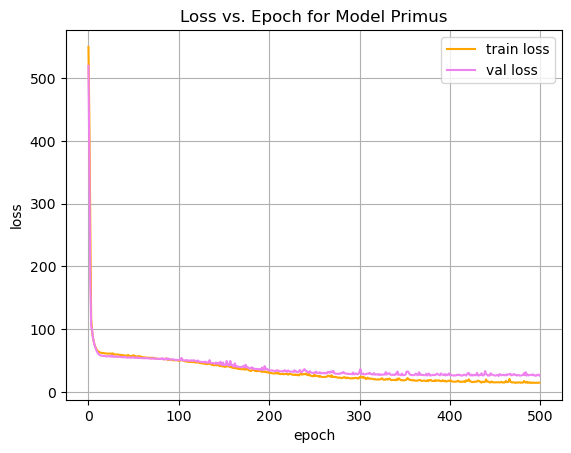

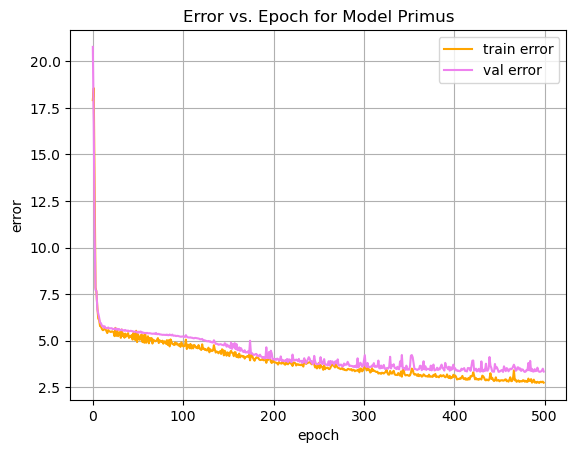

In [36]:
#Displaying results of Primus
#Plotting Loss v Epoch
loss_per_epoch = model.history.history['loss']
val_loss_per_epoch = model.history.history['val_loss']

plot_train_and_val_quantities(loss_per_epoch, val_loss_per_epoch,
                              "loss",
                              f"Loss vs. Epoch for Model {model.name}")

#Plotting Error v Epoch
error_per_epoch = model.history.history['mean_absolute_error']
val_error_per_epoch = model.history.history['val_mean_absolute_error']

plot_train_and_val_quantities(error_per_epoch, val_error_per_epoch,
                              "error",
                              f"Error vs. Epoch for Model {model.name}")

In [37]:
print_errors_at_last_epoch(error_per_epoch, val_error_per_epoch)

final_error: 2.7455389499664307
final val error: 3.342966079711914
final val - final train: 0.5974271297454834


In [38]:
# Creating a model with even more hidden layers
model = Sequential(name="Secundus")

#First hidden layer
model.add(keras.Input(shape=(13,)))
model.add(layers.Dense(64, activation='relu'))

#Second hidden layer
model.add(layers.Dense(64, activation='relu'))

#Third hidden layer
model.add(layers.Dense(64, activation='relu'))

#Output layer
model.add(layers.Dense(1,activation='linear'))

#Compiling
model.compile(loss = mse,
              optimizer= 'adam',
              metrics=[mae])
#Fitting
model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          epochs=EPOCHS,
          batch_size=BATCH_SIZE,
          verbose=2,
          shuffle=True)

Epoch 1/500
13/13 - 2s - loss: 562.9315 - mean_absolute_error: 18.1078 - val_loss: 562.2017 - val_mean_absolute_error: 21.7984 - 2s/epoch - 117ms/step
Epoch 2/500
13/13 - 0s - loss: 499.6564 - mean_absolute_error: 20.2340 - val_loss: 466.1727 - val_mean_absolute_error: 19.2927 - 63ms/epoch - 5ms/step
Epoch 3/500
13/13 - 0s - loss: 368.3289 - mean_absolute_error: 16.4658 - val_loss: 279.4532 - val_mean_absolute_error: 14.0455 - 62ms/epoch - 5ms/step
Epoch 4/500
13/13 - 0s - loss: 178.0332 - mean_absolute_error: 10.3824 - val_loss: 136.7662 - val_mean_absolute_error: 8.9082 - 65ms/epoch - 5ms/step
Epoch 5/500
13/13 - 0s - loss: 125.2254 - mean_absolute_error: 8.5920 - val_loss: 120.5621 - val_mean_absolute_error: 8.2961 - 63ms/epoch - 5ms/step
Epoch 6/500
13/13 - 0s - loss: 101.2870 - mean_absolute_error: 7.3790 - val_loss: 101.2587 - val_mean_absolute_error: 7.3688 - 64ms/epoch - 5ms/step
Epoch 7/500
13/13 - 0s - loss: 88.0894 - mean_absolute_error: 6.6158 - val_loss: 87.9121 - val_mean

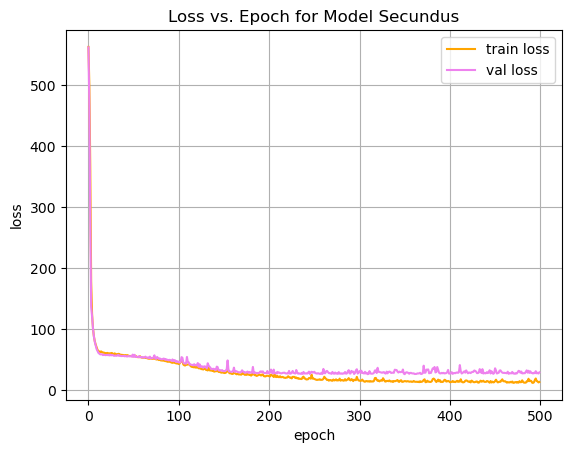

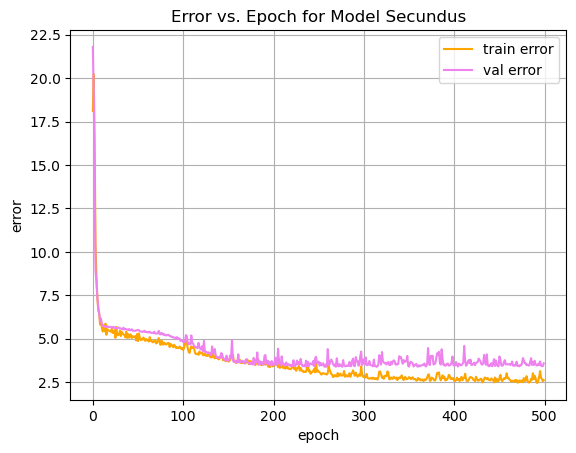

In [39]:
#Displaying results of Secundus
#Plotting Loss v Epoch
loss_per_epoch = model.history.history['loss']
val_loss_per_epoch = model.history.history['val_loss']

plot_train_and_val_quantities(loss_per_epoch, val_loss_per_epoch,
                              "loss",
                              f"Loss vs. Epoch for Model {model.name}")

#Plotting Error v Epoch
error_per_epoch = model.history.history['mean_absolute_error']
val_error_per_epoch = model.history.history['val_mean_absolute_error']

plot_train_and_val_quantities(error_per_epoch, val_error_per_epoch,
                              "error",
                              f"Error vs. Epoch for Model {model.name}")

In [40]:
print_errors_at_last_epoch(error_per_epoch, val_error_per_epoch)

final_error: 2.6162853240966797
final val error: 3.5879690647125244
final val - final train: 0.9716837406158447


In [41]:
# Creating a model with different regularization techniques
model = Sequential(name="Tertious")

#First hidden layer
model.add(Dense(64, activation='relu',
                  kernel_regularizer=l2(0.5),
                  bias_regularizer=l2(0.5),
                  input_shape=[13]))

#Second hidden layer
model.add(Dense(64, activation='relu',
                  kernel_regularizer=l2(0.5),
                  bias_regularizer=l2(0.5))),

#Output layer
model.add(Dense(1, activation='linear',
                       kernel_regularizer=l2(0.5),
                       bias_regularizer=l2(0.5)))
#Compiling
model.compile(loss = mse,
              optimizer= 'adam',
              metrics=[mae])

#Fitting
model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          epochs=EPOCHS,
          batch_size=BATCH_SIZE,
          verbose=2,
          shuffle=True)

Epoch 1/500
13/13 - 1s - loss: 599.6467 - mean_absolute_error: 18.0832 - val_loss: 598.8971 - val_mean_absolute_error: 21.7908 - 1s/epoch - 108ms/step
Epoch 2/500
13/13 - 0s - loss: 543.0825 - mean_absolute_error: 20.4762 - val_loss: 527.4810 - val_mean_absolute_error: 20.1467 - 62ms/epoch - 5ms/step
Epoch 3/500
13/13 - 0s - loss: 462.0887 - mean_absolute_error: 18.4409 - val_loss: 427.8387 - val_mean_absolute_error: 17.4895 - 62ms/epoch - 5ms/step
Epoch 4/500
13/13 - 0s - loss: 355.3630 - mean_absolute_error: 15.3230 - val_loss: 306.5047 - val_mean_absolute_error: 13.9665 - 61ms/epoch - 5ms/step
Epoch 5/500
13/13 - 0s - loss: 238.2060 - mean_absolute_error: 11.2985 - val_loss: 194.2926 - val_mean_absolute_error: 9.9998 - 62ms/epoch - 5ms/step
Epoch 6/500
13/13 - 0s - loss: 156.1984 - mean_absolute_error: 8.1466 - val_loss: 143.0402 - val_mean_absolute_error: 7.9142 - 63ms/epoch - 5ms/step
Epoch 7/500
13/13 - 0s - loss: 130.7724 - mean_absolute_error: 7.4074 - val_loss: 135.2391 - val_

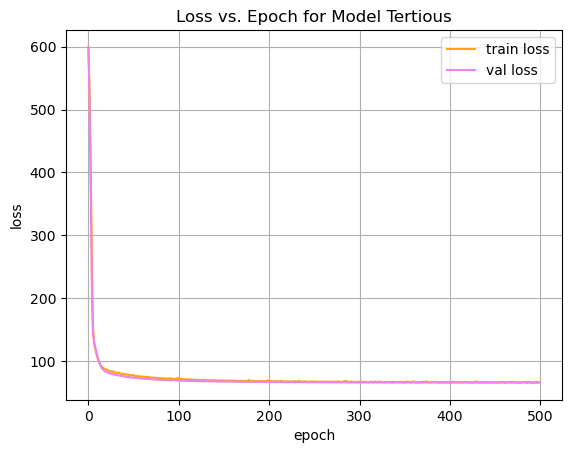

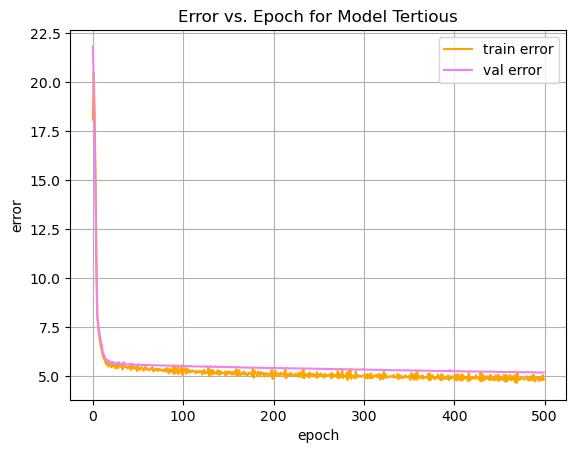

In [42]:
#Displaying results of Tertious
#Plotting Loss v Epoch
loss_per_epoch = model.history.history['loss']
val_loss_per_epoch = model.history.history['val_loss']

plot_train_and_val_quantities(loss_per_epoch, val_loss_per_epoch,
                              "loss",
                              f"Loss vs. Epoch for Model {model.name}")

#Plotting Error v Epoch
error_per_epoch = model.history.history['mean_absolute_error']
val_error_per_epoch = model.history.history['val_mean_absolute_error']

plot_train_and_val_quantities(error_per_epoch, val_error_per_epoch,
                              "error",
                              f"Error vs. Epoch for Model {model.name}")

In [43]:
print_errors_at_last_epoch(error_per_epoch, val_error_per_epoch)

final_error: 4.828406810760498
final val error: 5.200613975524902
final val - final train: 0.3722071647644043
